# UR3e base-frame calibration (mocap → robot base)

Recover the UR3e base frame **{B}** — origin `p0` and orientation `R0` — in the
motion-capture world frame **{W}**, using only what the cameras can see.

**Method (all closed form, no iterative regression):**
1. Sweep **joint 1** alone → the tracked rigid body traces a circle; its axis is
   the joint-1 (vertical) rotation axis.
2. Sweep **joint 2** alone → a second circle; its axis is the joint-2 axis.
3. The two joint axes intersect at the **shoulder** point → intersect the lines.
4. `p0 = shoulder − d1 · z0`  (`d1 = 0.15185 m`, `z0` = joint-1 axis up).
5. Two orientation-fixed base-frame probe moves (**+X**, **+Y**) give the base
   axes in {W} → orthonormalize → `R0`.

A base-frame point maps to world by `p_W = p0 + R0 @ p_B` (R0's columns are the
base axes in {W}). Output → `robots/UR3e/base_frame_calibration.json`.

> **Run Phase 1 first.** It is pure numpy (no hardware) and must recover a known
> frame to **< 1 mm** before you touch the robot.

## Setup

In [38]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

# Locate this calibration dir (kernel cwd may be the repo root or here).
_CANDIDATES = [os.getcwd(),
               os.path.join(os.getcwd(), "robots", "UR3e", "calibration")]
_HERE = next((c for c in _CANDIDATES
              if os.path.exists(os.path.join(c, "base_calibration_dependencies.py"))), None)
if _HERE is None:
    raise FileNotFoundError("base_calibration_dependencies.py not found near cwd")
sys.path.insert(0, _HERE)

import base_calibration_dependencies as cal

print("solver loaded from", cal.__file__)
print("d1 =", cal.UR3E_D1, "m")

solver loaded from /home/matthias-weiss/dev/zhaw/robotics/my_mujoco_playground/robots/UR3e/calibration/base_calibration_dependencies.py
d1 = 0.15185 m


## Phase 1 — synthetic check (no hardware)

Build two circles that share the shoulder point (so the joint axes truly
intersect), add 0.5 mm/point noise, and confirm `solve()` recovers the known
frame. These arrays also serve as the **dry-run** data for Phase 2.

In [39]:
def _rot_about(axis, ang):
    axis = np.asarray(axis, float); axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c, s, C = np.cos(ang), np.sin(ang), 1 - np.cos(ang)
    return np.array([
        [c + x*x*C, x*y*C - z*s, x*z*C + y*s],
        [y*x*C + z*s, c + y*y*C, y*z*C - x*s],
        [z*x*C - y*s, z*y*C + x*s, c + z*z*C]])

def _plane_basis(n):
    n = n / np.linalg.norm(n)
    a = np.array([1.,0.,0.]) if abs(n[0]) < 0.9 else np.array([0.,1.,0.])
    v1 = a - (a @ n) * n; v1 /= np.linalg.norm(v1)
    return v1, np.cross(n, v1)

rng = np.random.default_rng(0)
NOISE = 0.0005  # 0.5 mm/point
d1 = cal.UR3E_D1

# Ground-truth base frame in the world frame.
p0_true = np.array([0.612, -0.345, 0.018])
R0_true = _rot_about([0,0,1], np.deg2rad(37.0)) @ _rot_about([1,0,0], np.deg2rad(2.0))
z0_true, y0_true = R0_true[:, 2], R0_true[:, 1]
shoulder = p0_true + d1 * z0_true

# Joint-1 circle (axis z0 through the base/shoulder line).
c1 = shoulder + 0.22 * z0_true; r1 = 0.18
va, vb = _plane_basis(z0_true)
th = np.deg2rad(np.linspace(-85, 85, 40))
pts1 = c1 + r1*(np.cos(th)[:,None]*va + np.sin(th)[:,None]*vb)
pts1 = pts1 + rng.normal(0, NOISE, pts1.shape)

# Joint-2 circle (axis y0 through the SAME shoulder point).
c2 = shoulder + 0.10 * y0_true; r2 = 0.25
va, vb = _plane_basis(y0_true)
th = np.deg2rad(np.linspace(-80, 80, 40))
pts2 = c2 + r2*(np.cos(th)[:,None]*va + np.sin(th)[:,None]*vb)
pts2 = pts2 + rng.normal(0, NOISE, pts2.shape)

# Probe moves: +X, +Y in base frame, length L (orientation fixed).
L = 0.10
dp_x = R0_true @ np.array([L,0,0]) + rng.normal(0, NOISE, 3)
dp_y = R0_true @ np.array([0,L,0]) + rng.normal(0, NOISE, 3)
print(f"synthetic: {len(pts1)} J1 pts, {len(pts2)} J2 pts, L={L} m, noise={NOISE*1e3} mm")

synthetic: 40 J1 pts, 40 J2 pts, L=0.1 m, noise=0.5 mm


In [40]:
# Solve and check recovery against ground truth.
p0, R0, res = cal.solve(pts1, pts2, dp_x, dp_y, L, d1)

p0_err_mm = np.linalg.norm(p0 - p0_true) * 1e3
ang = np.degrees(np.arccos(np.clip((np.trace(R0.T @ R0_true) - 1)/2, -1, 1)))
print(f"p0_true  = {np.round(p0_true, 4)}")
print(f"p0_recov = {np.round(p0, 4)}")
print(f"p0 error          = {p0_err_mm:.3f} mm")
print(f"R0 geodesic error = {ang:.3f} deg")
print("residuals:")
for k, v in res.items():
    print(f"  {k:22s} = {v:8.4f}")

assert p0_err_mm < 1.0, f"p0 error {p0_err_mm:.3f} mm exceeds 1 mm"
assert ang < 1.0, f"R0 error {ang:.3f} deg too large"
print("\nPHASE 1 PASSED: p0 < 1 mm.")

p0_true  = [ 0.612 -0.345  0.018]
p0_recov = [ 0.6125 -0.3448  0.0179]
p0 error          = 0.561 mm
R0 geodesic error = 0.390 deg
residuals:
  circle1_rms_mm         =   0.4483
  circle2_rms_mm         =   0.5190
  circle1_radius_mm      = 179.9476
  circle2_radius_mm      = 250.1447
  axis_gap_h_mm          =   0.6179
  z0_vs_a1_deg           =   0.1760
  probe_x_len_err_mm     =   0.4162
  probe_y_len_err_mm     =   0.8537

PHASE 1 PASSED: p0 < 1 mm.


In [41]:
# Cross-check: full SVD+Kasa fit vs the 3-point circumcenter (circle 1).
c_fit, n_fit, rad_fit, _ = cal.fit_circle_3d(pts1)
idx = [0, len(pts1)//2, len(pts1)-1]
c_3pt, n_3pt = cal.circumcenter_3pt(*[pts1[i] for i in idx])
print(f"full-fit center  = {np.round(c_fit, 4)}  (r={rad_fit:.4f})")
print(f"3-point center   = {np.round(c_3pt, 4)}")
print(f"center disagreement = {np.linalg.norm(c_fit - c_3pt)*1e3:.3f} mm")
print(f"axis angle diff     = {np.degrees(np.arccos(np.clip(abs(n_fit@n_3pt),-1,1))):.3f} deg")

full-fit center  = [ 0.6198 -0.3555  0.3896]  (r=0.1799)
3-point center   = [ 0.6192 -0.3552  0.39  ]
center disagreement = 0.779 mm
axis angle diff     = 0.072 deg


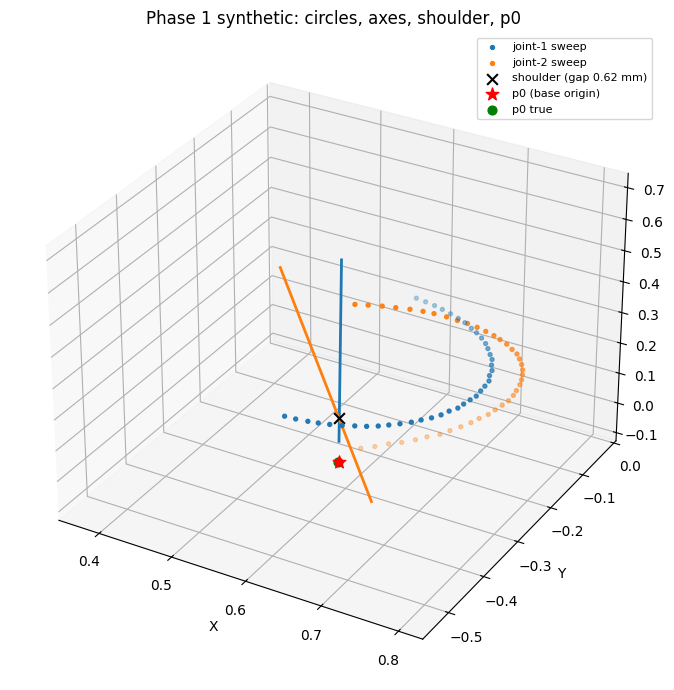

In [42]:
# Visualize: the two circles, their axes, the shoulder, and p0.
c1f, a1f, r1f, _ = cal.fit_circle_3d(pts1)
c2f, a2f, r2f, _ = cal.fit_circle_3d(pts2)
P1, P2, gap = cal.closest_point_two_lines(c1f, a1f, c2f, a2f)

fig = plt.figure(figsize=(8, 7)); ax = fig.add_subplot(111, projection="3d")
ax.scatter(*pts1.T, s=8, label="joint-1 sweep")
ax.scatter(*pts2.T, s=8, label="joint-2 sweep")
for c, a, col in [(c1f, a1f, "C0"), (c2f, a2f, "C1")]:
    seg = np.stack([c - 0.3*a, c + 0.3*a])
    ax.plot(*seg.T, col, lw=2)
ax.scatter(*P1, c="k", s=60, marker="x", label=f"shoulder (gap {gap*1e3:.2f} mm)")
ax.scatter(*p0, c="r", s=90, marker="*", label="p0 (base origin)")
ax.scatter(*p0_true, c="g", s=40, marker="o", label="p0 true")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z"); ax.legend(fontsize=8)
ax.set_title("Phase 1 synthetic: circles, axes, shoulder, p0"); plt.tight_layout(); plt.show()

---
## Phase 2 — hardware

**Safety / procedure**
- `DRY_RUN = True` reuses the Phase 1 synthetic arrays so the whole pipeline runs
  with **no robot and no mocap**. Set it `False` only at the robot, after Phase 1
  passes.
- The robot is gated: `connect()` **blocks until the External Control program is
  PLAYING** on the pendant (pressing **Play** is the robot-side "go").
- **Only one joint moves per sweep.** Low speed/accel. Keep `calibrig4` off both
  rotation axes and camera-visible across the whole sweep.
- The orientation probe uses the **raw** RTDE TCP pose (`getActualTCPPose()`),
  NOT `receive_feedback()` — the latter negates X/Y for the policy obs frame.

In [ ]:
# --- CONFIG ---
DRY_RUN = False                # LIVE: drives the real robot + mocap (Phase 1 must have passed)

ROBOT_IP        = "192.168.1.4"     # UR3e on PolyScope X
USE_EXT_URCAP   = True               # External Control URCapX go-gate
UR_CAP_PORT     = 50002

MOCAP_SERVER_IP = "10.1.1.198"
RIGID_BODY      = "calibrig4"        # tracked rigid body on the arm

# Safe, self-collision-free start (rad), rounded from a measured q and verified
# collision-free in the MuJoCo UR3 model. Each sweep moves ONE joint to an absolute
# target, holding the rest:
#   joint 0 (base)     -1.5 -> +1.5  (~172 deg arc)
#   joint 1 (shoulder)  0.0 -> -3.0  (~172 deg arc, base held at +1.5)
# Verify visibility at the robot and jog if a camera is occluded, then re-read q.
Q_SAFE_START      = np.array([-1.5, 0.0, 0.0, -1.7, 0.0, 0.0])
BASE_SWEEP_TO     = 1.5             # joint 0 sweep end (rad)
SHOULDER_SWEEP_TO = -3.0            # joint 1 sweep end (rad)
Q_TASK_HOME       = np.array([0.0, -2.0, 1.6, -1.6, -1.5, 0.0])  # probe pose + final park (XML keyframe)

MOVE_A  = 0.2             # rad/s^2, shared MoveJ acceleration
START_V = 0.6             # rad/s, move-to-position velocity
SWEEP_V = 0.4             # rad/s, sweep velocity
PROBE_L = 0.10            # m, probe move length (orientation fixed)
PROBE_V = 0.03            # m/s
PROBE_A = 0.1            # m/s^2

OUT_JSON = os.path.join(_HERE, "base_frame_calibration.json")
OUT_PNG  = os.path.join(_HERE, "base_frame_calibration.png")
print("DRY_RUN =", DRY_RUN, "| output ->", OUT_JSON)

In [44]:
# Connect mocap (skipped in DRY_RUN). Verify data is flowing and units are meters.
reader = None
if not DRY_RUN:
    _REPO_ROOT = os.path.abspath(os.path.join(_HERE, "..", "..", ".."))
    sys.path.insert(0, os.path.join(_REPO_ROOT, "motion_capture", "mymocap"))
    from vrpn_dependencies import VRPNRigidBodyReader
    reader = VRPNRigidBodyReader(MOCAP_SERVER_IP, rigid_body_name=RIGID_BODY,
                                 names=[RIGID_BODY])
    assert reader.start(timeout=8.0), "VRPN subscribe failed"
    assert reader.wait_for_data(timeout=5.0), f"no reports for '{RIGID_BODY}'"
    xyz = reader.get_rigid_body_xyz()
    print(f"'{RIGID_BODY}' @ {np.round(xyz, 3)} m  (|xyz|={np.linalg.norm(xyz):.3f} m)")
    assert np.linalg.norm(xyz) < 10.0, "xyz looks like mm, not meters!"
else:
    print("DRY_RUN: skipping mocap connect.")

[VRPN] Connecting to 10.1.1.198:3883 ...
[VRPN] ✓ Subscribed to 1 tracker(s): ['calibrig4']
'calibrig4' @ [-0.404 -0.062  1.415] m  (|xyz|=1.473 m)


In [45]:
# Connect robot + go-gate (skipped in DRY_RUN). Blocks until Play on the pendant.
robot = None
if not DRY_RUN:
    sys.path.insert(0, os.path.dirname(_HERE))  # robots/UR3e
    from ur3_realrobot_dependencies import UR3RealRobotPick
    robot = UR3RealRobotPick(host=ROBOT_IP, use_ext_urcap=USE_EXT_URCAP,
                             ur_cap_port=UR_CAP_PORT)
    print("Press PLAY on the pendant (External Control) to release the go-gate...")
    robot.connect()
    robot.print_feedback()
    print("connected:", robot.is_connected())
else:
    print("DRY_RUN: skipping robot connect.")

Press PLAY on the pendant (External Control) to release the go-gate...
Waiting for RTDE control program to be running on the controller
q      = [-0.501, -1.0618, 0.1113, -1.6337, 0.0045, -0.0917]
qd     = [0.0, 0.0, 0.0, -0.0, 0.0, 0.0]
tcp_xyz= [0.3595, 0.0578, 0.61]
connected: True


In [ ]:
# Move to the safe start (skipped in DRY_RUN).
if not DRY_RUN:
    robot.send_movej(Q_SAFE_START, a=MOVE_A, v=START_V, asynchronous=False)
    assert reader.get_rigid_body_xyz() is not None, "calibrig4 not visible at start!"
    print("at safe start; calibrig4 visible.")
else:
    print("DRY_RUN: skipping move-to-start.")

In [ ]:
# Recording + analysis helpers - identical to base_calibration.py.
def sweep_joint(robot, reader, joint_idx, q_start, target, hz=30.0, timeout=60.0):
    """Move one joint to `target` (rad) async, logging mocap xyz while it travels."""
    q_goal = np.asarray(q_start, float).copy()
    q_goal[joint_idx] = target
    robot.send_movej(q_goal, a=MOVE_A, v=SWEEP_V)
    pts, t0 = [], time.perf_counter()
    while True:
        q = np.array(robot.receive_feedback()["q"])
        xyz = reader.get_rigid_body_xyz()
        if xyz is not None:
            pts.append(xyz)
        if np.linalg.norm(q - q_goal) < 0.01 or time.perf_counter() - t0 > timeout:
            break
        time.sleep(1.0 / hz)
    return np.array(pts)


def probe_axis(robot, reader, axis_idx, settle=0.6):
    """Orientation-fixed +axis move of PROBE_L; return the mocap displacement."""
    r = robot.connect()
    p_before = reader.get_rigid_body_xyz().copy()
    pose0 = r.getActualTCPPose()              # RAW base pose (not the negated obs frame)
    pose1 = list(pose0)
    pose1[axis_idx] += PROBE_L
    robot._control.moveL(pose1, PROBE_V, PROBE_A)
    time.sleep(settle)
    p_after = reader.get_rigid_body_xyz().copy()
    robot._control.moveL(list(pose0), PROBE_V, PROBE_A)
    return p_after - p_before


def plot_calibration(pts1, pts2, p0, tcp_world, mocap_world, out_png):
    """3D plot: sweep trajectories, fitted axes, shoulder, p0, and the
    RTDE TCP vs mocap calibrig4 (both in the robot world frame) + their gap."""
    c1f, a1f, _, _ = cal.fit_circle_3d(pts1)
    c2f, a2f, _, _ = cal.fit_circle_3d(pts2)
    shoulder, _, gap = cal.closest_point_two_lines(c1f, a1f, c2f, a2f)
    dist_mm = np.linalg.norm(tcp_world - mocap_world) * 1e3

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(*pts1.T, s=8, label="joint-1 sweep")
    ax.scatter(*pts2.T, s=8, label="joint-2 sweep")
    for c, a, col in [(c1f, a1f, "C0"), (c2f, a2f, "C1")]:
        seg = np.stack([c - 0.3 * a, c + 0.3 * a])
        ax.plot(*seg.T, col, lw=2)
    ax.scatter(*shoulder, c="k", s=60, marker="x",
               label=f"shoulder (gap {gap * 1e3:.2f} mm)")
    ax.scatter(*p0, c="r", s=90, marker="*", label="p0 (base origin)")
    ax.scatter(*tcp_world, c="m", s=70, marker="^", label="Robot RTDE TCP")
    ax.scatter(*mocap_world, c="g", s=70, marker="o", label="mocap calibrig4")
    gap_seg = np.stack([tcp_world, mocap_world])
    ax.plot(*gap_seg.T, "k--", lw=1.5, label=f"|TCP - body| = {dist_mm:.1f} mm")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.legend(fontsize=8)
    ax.set_title("UR3e base-frame calibration (robot world frame)")
    plt.tight_layout()
    fig.savefig(out_png, dpi=150)
    print("wrote", out_png)
    plt.show()


def print_axis_quality(R0, dp_x, dp_y, res):
    """Report how far the recovered base axes are from ideal.

    The probes measure base +X and +Y directly; ideally those two directions are
    orthogonal (90 deg) and their cross product (the base Z) matches the joint-1
    rotation axis from the sweep (0 deg). The deviation from 90 deg is exactly the
    correction Gram-Schmidt applied to make R0 orthonormal.
    """
    x = dp_x / np.linalg.norm(dp_x)
    y = dp_y / np.linalg.norm(dp_y)
    ang_xy = np.degrees(np.arccos(np.clip(x @ y, -1.0, 1.0)))   # measured X^Y angle
    ortho_err = ang_xy - 90.0                                   # ideal 0
    z_vs_axis = res["z0_vs_a1_deg"]                             # probe Z vs joint-1 axis, ideal 0
    orthonormality = np.linalg.norm(R0.T @ R0 - np.eye(3))      # ideal 0
    det = np.linalg.det(R0)                                     # ideal +1
    print("Axis calibration error (recovered vs ideal):")
    print(f"  base X^Y angle    = {ang_xy:7.3f} deg  (ideal 90.000 -> err {ortho_err:+.3f} deg)")
    print(f"  base Z vs joint-1 = {z_vs_axis:7.3f} deg  (ideal  0.000)")
    print(f"  R0 orthonormality = {orthonormality:.2e}      (ideal 0; det = {det:.4f}, ideal 1)")

print("helpers defined.")

In [ ]:
# Joint-1 half-circle: base -1.5 -> +1.5 (hold q2..q6). DRY_RUN keeps the Phase 1 array.
if not DRY_RUN:
    pts1 = sweep_joint(robot, reader, 0, Q_SAFE_START, BASE_SWEEP_TO)
    print(f"joint-1: recorded {len(pts1)} points")
else:
    print(f"DRY_RUN: using synthetic pts1 ({len(pts1)} points)")

In [ ]:
# Joint-2 half-circle: shoulder 0 -> -3.0 with the base held at +1.5 (end of the
# joint-1 sweep). DRY_RUN keeps the Phase 1 array.
if not DRY_RUN:
    q2_base = Q_SAFE_START.copy(); q2_base[0] = BASE_SWEEP_TO
    robot.send_movej(q2_base, a=MOVE_A, v=START_V, asynchronous=False)
    pts2 = sweep_joint(robot, reader, 1, q2_base, SHOULDER_SWEEP_TO)
    print(f"joint-2: recorded {len(pts2)} points")
else:
    print(f"DRY_RUN: using synthetic pts2 ({len(pts2)} points)")

In [ ]:
# Orientation probe (Option A): +X then +Y, orientation fixed. DRY_RUN keeps arrays.
# Blocking move to Q_TASK_HOME (elbow bent -> non-singular) so the arm is fully
# stopped before the Cartesian probes; this pose also doubles as the final rest
# position (probe_axis returns here after each probe).
if not DRY_RUN:
    robot.send_movej(Q_TASK_HOME, a=MOVE_A, v=START_V, asynchronous=False)
    dp_x = probe_axis(robot, reader, 0)
    dp_y = probe_axis(robot, reader, 1)
    print(f"dp_x = {np.round(dp_x,4)} (|{np.linalg.norm(dp_x):.4f}|)")
    print(f"dp_y = {np.round(dp_y,4)} (|{np.linalg.norm(dp_y):.4f}|)")
else:
    print("DRY_RUN: using synthetic dp_x, dp_y")

In [51]:
# Solve from the (live or dry-run) data and write the JSON.
import json
from datetime import datetime

p0, R0, res = cal.solve(pts1, pts2, dp_x, dp_y, PROBE_L if not DRY_RUN else L, d1)
out = cal.build_output_dict(
    p0, R0, res, n_points_j1=len(pts1), n_points_j2=len(pts2),
    rigid_body=RIGID_BODY, d1=d1, timestamp=datetime.now().isoformat(timespec="seconds"))

print("p0 (m) =", np.round(p0, 4))
print("R0 =\n", np.round(R0, 4))
print("residuals:")
for k, v in res.items():
    print(f"  {k:22s} = {v:8.4f}")
print(f"\naxis gap h = {res['axis_gap_h_mm']:.2f} mm   (smaller = better)")

if not DRY_RUN:
    with open(OUT_JSON, "w") as f:
        json.dump(out, f, indent=2)
    print("wrote", OUT_JSON)
else:
    print("DRY_RUN: not writing JSON. Preview:")
    print(json.dumps(out, indent=2))

p0 (m) = [-0.0098  0.002   0.7712]
R0 =
 [[-0.5937 -0.4734 -0.6507]
 [ 0.7153 -0.6809 -0.1571]
 [-0.3687 -0.5587  0.7429]]
residuals:
  circle1_rms_mm         =   0.2813
  circle2_rms_mm         =   0.2457
  circle1_radius_mm      = 632.3987
  circle2_radius_mm      = 588.3890
  axis_gap_h_mm          =   0.2385
  z0_vs_a1_deg           =  40.9412
  probe_x_len_err_mm     = -98.2436
  probe_y_len_err_mm     = -88.2159

axis gap h = 0.24 mm   (smaller = better)
wrote /home/matthias-weiss/dev/zhaw/robotics/my_mujoco_playground/robots/UR3e/calibration/base_frame_calibration.json


In [ ]:
# TCP cross-check + axis quality + plot (skipped in DRY_RUN).
if not DRY_RUN:
    # Map the RTDE TCP (raw base frame) into the mocap world via the fresh
    # calibration and compare to the tracked body. The residual is the fixed
    # calibrig4->TCP mount offset (not zero), but should be small and stable.
    tcp_base = np.array(robot.connect().getActualTCPPose()[:3])
    tcp_world = p0 + R0 @ tcp_base
    mocap_world = reader.get_rigid_body_xyz()
    print("TCP cross-check (mocap world frame):")
    print(f"  RTDE TCP  -> world = {np.round(tcp_world, 4)} m")
    print(f"  mocap calibrig4    = {np.round(mocap_world, 4)} m")
    print(f"  |TCP - body| = {np.linalg.norm(tcp_world - mocap_world) * 1e3:.1f} mm"
          "  (= calibrig4->TCP mount offset)")
    # Already parked at Q_TASK_HOME (probe_axis returned the arm there).

    print_axis_quality(R0, dp_x, dp_y, res)
    plot_calibration(pts1, pts2, p0, tcp_world, mocap_world, OUT_PNG)
else:
    print("DRY_RUN: skipping TCP cross-check / axis quality / plot.")

In [1]:
# Sanity check: p0 vs where the robot stands. The base origin should be near the
# floor (small Z in {W} if the world Z is up) and within the workspace footprint.
print(f"p0 = {np.round(p0, 4)} m")
print(f"shoulder height recovered along z0: d1 used = {d1:.5f} m")
if not DRY_RUN:
    print("Compare p0 to a tape-measure estimate of the base origin in mocap coords.")
    robot.disconnect(); reader.stop()
    print("disconnected.")

NameError: name 'np' is not defined